# MLP Classifier

Import das Bibliotecas necessárias

In [127]:
import matplotlib.pyplot as plt
import json
import librosa
import pandas as pd
import os
import numpy as np
import soundfile as sf
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import ParameterGrid
import seaborn as sns
import random
import time


import tensorflow as tf
from tensorflow.keras import layers, models # type: ignore
from tensorflow.keras.utils import to_categorical, plot_model # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # type: ignore
from tensorflow.keras.regularizers import l2 # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization # type: ignore
from tensorflow.keras.optimizers import Adam, Nadam # type: ignore
from tqdm.keras import TqdmCallback
from sklearn.metrics import accuracy_score, classification_report


Load das informações do pré-processamento

In [124]:
# Carregar as informações do pré-processamento
with open('processing_info.json', "r") as f:
    processing_info = json.load(f)
metadata_path = processing_info['metadata_path']
metadata_augmented_path = processing_info['metadata_augmented_path']
audio_base_path = processing_info['audio_base_path']
audios_4sec_path = processing_info['audio_4sec_path']
audio_4sec_aug_path = processing_info['audio_4sec_aug_path']
sr = processing_info['sample_rate']

metadata_augmented = pd.read_csv(metadata_augmented_path)

## 1. Data Pre-Processing and Data Preparation for MLP

### 1.1. Feature Extraction
#### Extração de um conjunto abrangente de características acústicas
MFCCs, deltas, descritores espectrais, cromas, mel-spectrograma e tonnetz - convertendo cada ficheiro áudio num vetor numérico fixo, adequado para treinar o modelo MLP.

In [91]:
def extract_mlp_features(audio_file, target_sr=sr):
    try:
        y, sr = librosa.load(audio_file, sr=target_sr)
        features = []

        # MFCC + delta + delta2
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_mels=40)
        for i in range(13):
            features.extend([np.mean(mfccs[i]), np.std(mfccs[i])])
            mfcc_delta = librosa.feature.delta(mfccs[i])
            features.extend([np.mean(mfcc_delta), np.std(mfcc_delta)])

        # Spectral features
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(y)
        for feature in [spectral_centroid, spectral_rolloff, zcr]:
            features.extend([np.mean(feature), np.std(feature), np.max(feature)-np.min(feature)])

        # Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        for i in range(6):
            features.extend([np.mean(chroma[i]), np.std(chroma[i])])

        # Mel Spectrogram
        mel = librosa.feature.melspectrogram(y=y, sr=sr)
        features.extend([np.mean(mel), np.std(mel)])

        # Tonnetz
        y_harm = librosa.effects.harmonic(y)
        tonnetz = librosa.feature.tonnetz(y=y_harm, sr=sr)
        for i in range(6):
            features.extend([np.mean(tonnetz[i]), np.std(tonnetz[i])])

        return np.array(features, dtype=np.float32)

    except Exception as e:
        print(f"Erro ao processar {audio_file}: {e}")
        return None


Extrair as Features e as Labels de todos os ficheiros mantendo a estrutura de Cross Validation

In [92]:
# Estrutura para guardar features
x_folds_orig = []
y_folds_orig = []

x_folds_aug = []
y_folds_aug = []

folders = sorted([f for f in os.listdir(audio_4sec_aug_path) if os.path.isdir(os.path.join(audio_4sec_aug_path, f))])

for folder in folders:
    folder_path = os.path.join(audio_4sec_aug_path, folder)
    audio_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]

    X_orig, Y_orig = [], []
    X_aug, Y_aug = [], []

    print(f"Processando {folder}: {len(audio_files)} arquivos")
    for file in tqdm(audio_files, desc=f"Extraindo features {folder}"):
        file_path = os.path.join(folder_path, file)
        features = extract_mlp_features(file_path)

        if features is None:
            continue

        # Obter label
        row = metadata_augmented[metadata_augmented['slice_file_name'] == file]
        if row.empty:
            print(f"Aviso: arquivo {file} não encontrado no metadata. Ignorado.")
            continue
        label = int(row['classID'].values[0])

        # Separar originais e augmentados
        if file.startswith("aug_"):
            X_aug.append(features)
            Y_aug.append(label)
        else:
            X_orig.append(features)
            Y_orig.append(label)

    # Converter listas para arrays e salvar fold
    x_folds_orig.append(np.array(X_orig, dtype=np.float32))
    y_folds_orig.append(np.array(Y_orig, dtype=np.int32))

    x_folds_aug.append(np.array(X_aug, dtype=np.float32))
    y_folds_aug.append(np.array(Y_aug, dtype=np.int32))


Processando fold10_4sec: 940 arquivos


Extraindo features fold10_4sec:   9%|▉         | 83/940 [00:11<01:57,  7.29it/s]/opt/anaconda3/envs/AC2_proj/lib/python3.12/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Extraindo features fold10_4sec: 100%|██████████| 940/940 [02:13<00:00,  7.03it/s]


Processando fold1_4sec: 987 arquivos


Extraindo features fold1_4sec: 100%|██████████| 987/987 [02:19<00:00,  7.06it/s]


Processando fold2_4sec: 1010 arquivos


...

Extraindo features fold7_4sec: 100%|██████████| 966/966 [02:19<00:00,  6.90it/s]


Processando fold8_4sec: 902 arquivos


Extraindo features fold8_4sec: 100%|██████████| 902/902 [02:07<00:00,  7.08it/s]


Processando fold9_4sec: 917 arquivos


Extraindo features fold9_4sec: 100%|██████████| 917/917 [02:09<00:00,  7.07it/s]


### 1.2. Análise da Qualidade dos Dados

Verificação das dimensões dos dados em cada fold, tanto para amostras originais como aumentadas, garantindo que a extração de features e a organização do dataset foram realizadas corretamente.

In [93]:
print("\nShapes por fold (originais):")
for i, (x, y) in enumerate(zip(x_folds_orig, y_folds_orig), 1):
    print(f"Fold {i}: X={x.shape}, Y={y.shape}")

print("\nShapes por fold (augmentados):")
for i, (x, y) in enumerate(zip(x_folds_aug, y_folds_aug), 1):
    print(f"Fold {i}: X={x.shape}, Y={y.shape}")



Shapes por fold (originais):
Fold 1: X=(837, 87), Y=(837,)
Fold 2: X=(873, 87), Y=(873,)
Fold 3: X=(888, 87), Y=(888,)
Fold 4: X=(925, 87), Y=(925,)
Fold 5: X=(990, 87), Y=(990,)
Fold 6: X=(936, 87), Y=(936,)
Fold 7: X=(823, 87), Y=(823,)
Fold 8: X=(838, 87), Y=(838,)
Fold 9: X=(806, 87), Y=(806,)
Fold 10: X=(816, 87), Y=(816,)

Shapes por fold (augmentados):
Fold 1: X=(103, 87), Y=(103,)
Fold 2: X=(114, 87), Y=(114,)
Fold 3: X=(122, 87), Y=(122,)
Fold 4: X=(126, 87), Y=(126,)
Fold 5: X=(156, 87), Y=(156,)
Fold 6: X=(202, 87), Y=(202,)
Fold 7: X=(120, 87), Y=(120,)
Fold 8: X=(128, 87), Y=(128,)
Fold 9: X=(96, 87), Y=(96,)
Fold 10: X=(101, 87), Y=(101,)


A função check_invalid_values realiza uma verificação de integridade dos dados armazenados nos folds.

In [95]:
def check_invalid_values(x_folds):
    for i, x in enumerate(x_folds, 1):
        if np.any(np.isnan(x)):
            print(f"Fold {i} contém NaN")
        if np.any(np.isinf(x)):
            print(f"Fold {i} contém Inf")
        if np.all(x == 0):
            print(f"Fold {i} contém apenas zeros")
            
check_invalid_values(x_folds_orig)
check_invalid_values(x_folds_aug)


## 2. Model Architecture - MLP Architecture Design


- Input Layer
    -> Camada de entrada que recebe o vetor de features extraídas do áudio (MFCC, delta, spectral, chroma, etc.).

- 1ª Dense Layer
    - 128 neurónios totalmente conectados que aprendem padrões complexos nas features de entrada.
    - Ativação ReLU: se o padrão é detetado ativa o neurónio, caso contrário fica 0.
    - Regularização L2: ajuda a reduzir overfitting penalizando pesos grandes.
    - BatchNormalization: normaliza os outputs da camada, acelerando e estabilizando o treino.
    - Dropout 0.3: desliga aleatoriamente 30% dos neurónios para reduzir overfitting.

- 2ª Dense Layer
    - 64 neurónios que combinam as features aprendidas anteriormente.
    - ReLU + L2 + BatchNormalization.
    - Dropout 0.2: desliga 20% dos neurónios, menor do que na primeira camada por ser mais profunda.

- 3ª Dense Layer
    - 32 neurónios, camada mais pequena que consolida as features mais importantes.
    - ReLU + L2 + BatchNormalization.
    - Dropout 0.1: redução do overfitting ligeira, pois é a camada mais interna antes da saída.
    
- Output Layer
    -> Número de neurónios igual ao número de classes
    - Softmax: converte os outputs em probabilidades de cada classe, permitindo a classificação final.

In [ ]:
def create_mlp_model(input_shape, num_classes=10):
    model = Sequential()
    
    # Input Layer
    model.add(Input(shape=input_shape))
    
    # 1ª Dense Layer
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    
    # 2ª Dense Layer
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))
    
    # 3ª Dense Layer
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    
    # Output Layer
    model.add(Dense(num_classes, activation='softmax'))
    
    # Compilação do modelo
    model.compile(
        loss="categorical_crossentropy",
        optimizer=Adam(1e-4),
        metrics=["accuracy"]
    )
    
    return model

# Callback EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


In [97]:
# Input shape: número de features (87 para o MLP)
input_shape = (x_folds_orig[0].shape[1],)  # 1D vector

mlp_model = create_mlp_model(input_shape)
print("MLP Model Architecture Defined")
mlp_model.summary()


MLP Model Architecture Defined


Model: "sequential_1287"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5156 (Dense)              │ (None, 128)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3855        │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3855 (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5157 (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3856        │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3856 (Dropout)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5158 (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3857        │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3857 (Dropout)          │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5159 (Dense)              │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,826 (89.16 KB)

 Trainable params: 22,378 (87.41 KB)

 Non-trainable params: 448 (1.75 KB)

## 4. Performance evaluation

Avaliar o desempenho do modelo através de 10-fold cross-validation e da visualização das métricas de treino e validação, incluindo gráficos de accuracy, loss e confusion matrix.


=========== INICIANDO 10-FOLD CROSS-VALIDATION ===========

---------------------- FOLD 1 ----------------------
Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.1566 - loss: 2.8483 - val_accuracy: 0.2417 - val_loss: 2.4028
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2323 - loss: 2.5362 - val_accuracy: 0.2829 - val_loss: 2.2293
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2936 - loss: 2.3235 - val_accuracy: 0.3551 - val_loss: 2.0811
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3462 - loss: 2.1684 - val_accuracy: 0.4032 - val_loss: 1.9639
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3756 - loss: 2.0565 - val_accuracy: 0.4513 - val_loss: 1.8688
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4032 - loss: 1.9790 - val_accuracy: 0.4788 - val_loss: 1.7923
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4270 - loss: 1.9028 - val_accuracy: 0.4983 - val_loss: 1.7300
Epoc

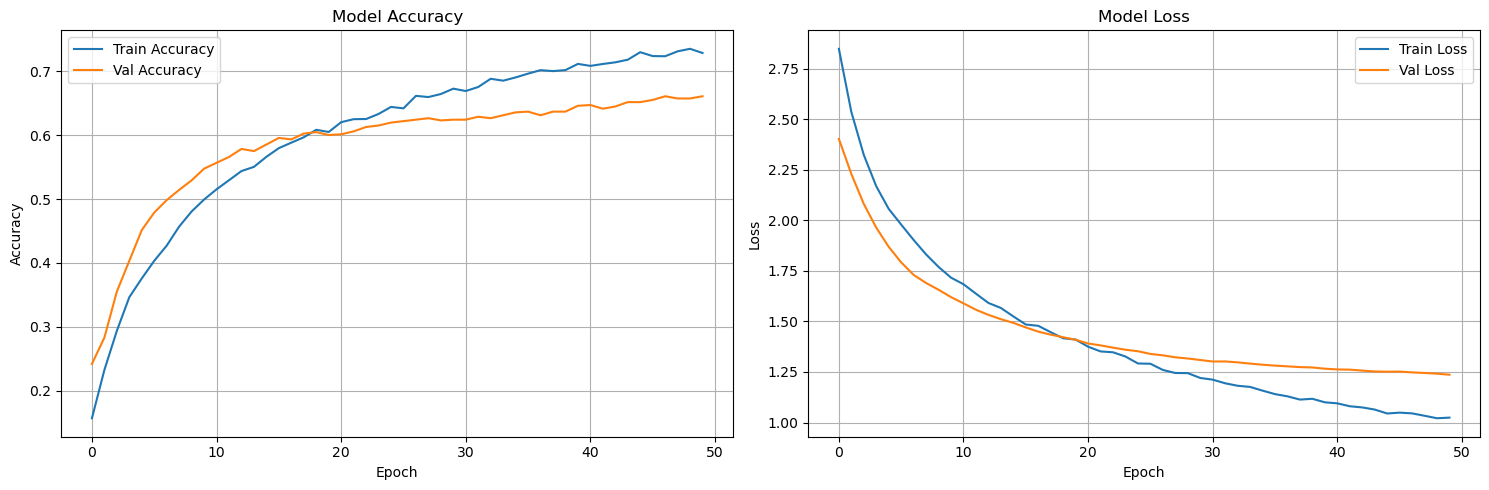

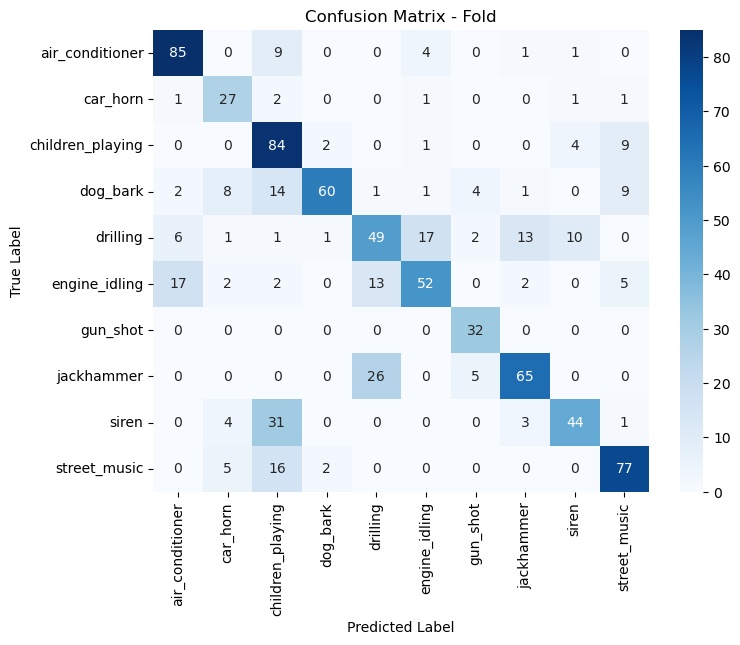


---------------------- FOLD 2 ----------------------
Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1386 - loss: 2.9370 - val_accuracy: 0.1914 - val_loss: 2.3839
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2247 - loss: 2.5802 - val_accuracy: 0.2680 - val_loss: 2.2279
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2931 - loss: 2.3105 - val_accuracy: 0.3266 - val_loss: 2.0885
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3537 - loss: 2.1387 - val_accuracy: 0.3727 - val_loss: 1.9790
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3915 - loss: 2.0209 - val_accuracy: 0.4268 - val_loss: 1.8951
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4208 - loss: 1.9214 - val_accuracy: 0.4606 - val_loss: 1.8249
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4503 - loss: 1.8552 - val_accuracy: 0.4752 - val_loss: 1.7616
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.

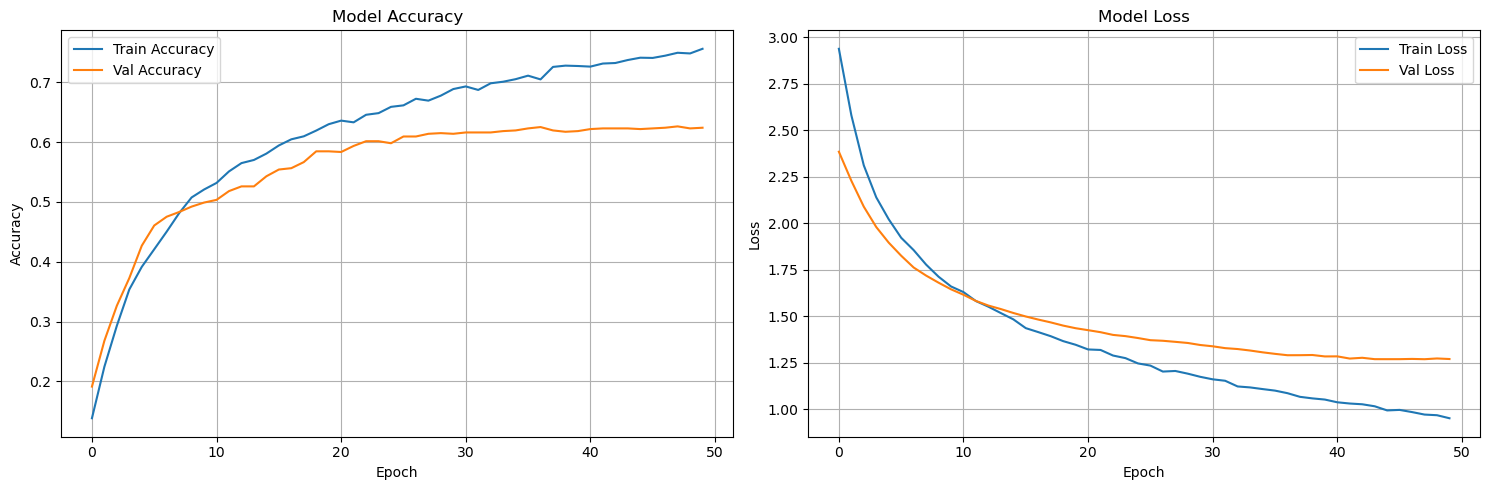

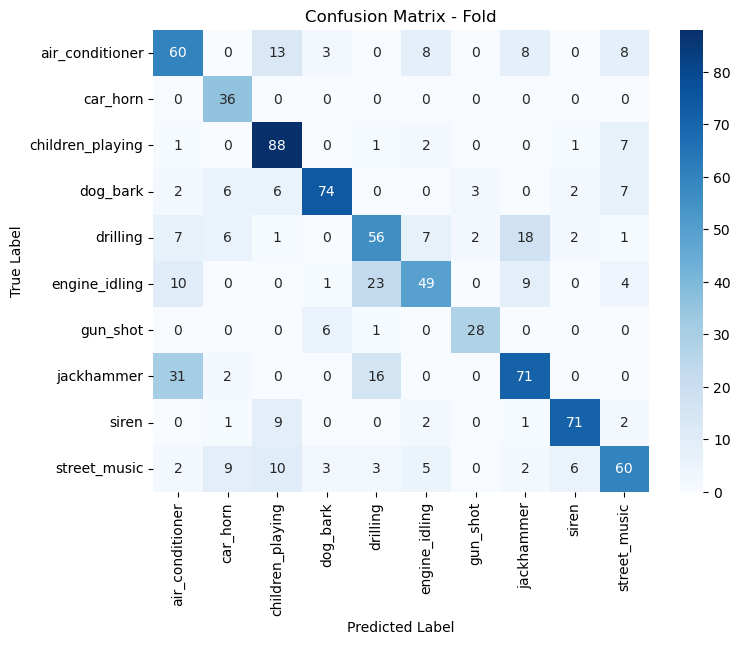


---------------------- FOLD 3 ----------------------
Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1600 - loss: 2.8334 - val_accuracy: 0.2541 - val_loss: 2.3819
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2422 - loss: 2.4505 - val_accuracy: 0.3178 - val_loss: 2.2338
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3010 - loss: 2.2629 - val_accuracy: 0.3654 - val_loss: 2.1033
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3516 - loss: 2.1096 - val_accuracy: 0.4054 - val_loss: 2.0010
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3799 - loss: 2.0243 - val_accuracy: 0.4389 - val_loss: 1.9278
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4143 - loss: 1.9250 - val_accuracy: 0.4530 - val_loss: 1.8776
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4428 - loss: 1.8631 - val_accuracy: 0.4519 - val_loss: 1.8364
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.

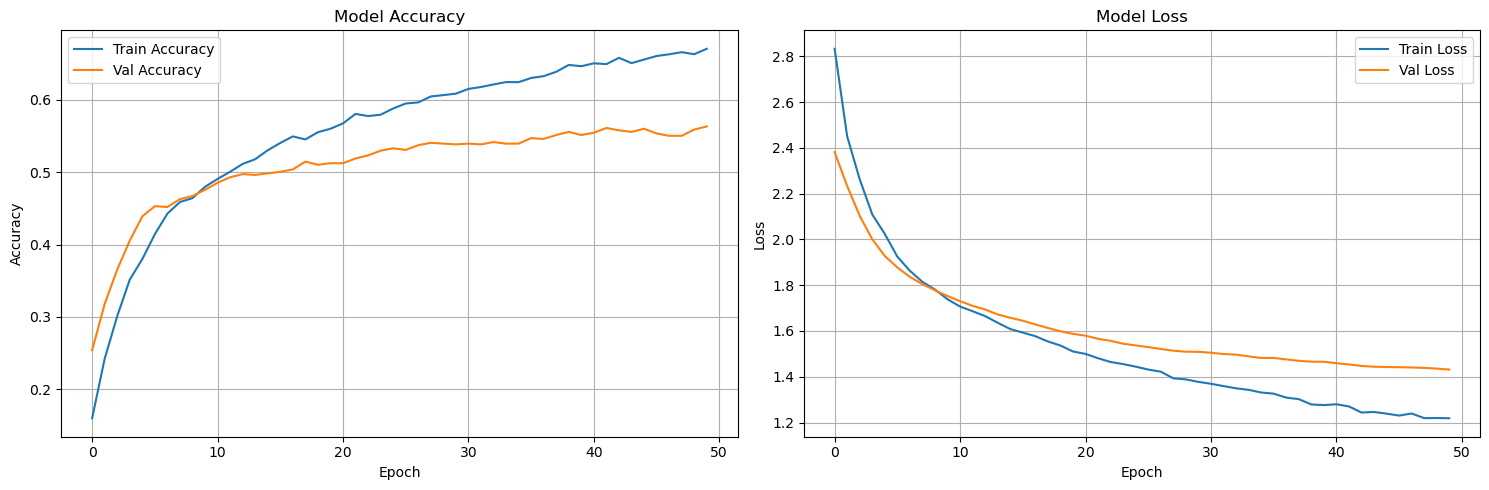

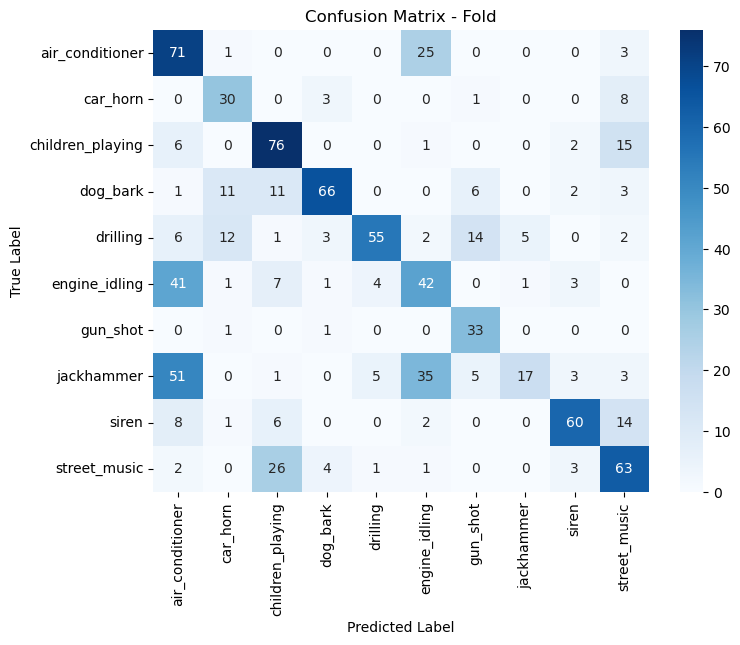


---------------------- FOLD 4 ----------------------
Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1037 - loss: 3.0972 - val_accuracy: 0.1273 - val_loss: 2.5043
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1826 - loss: 2.6735 - val_accuracy: 0.2010 - val_loss: 2.3760
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2589 - loss: 2.3763 - val_accuracy: 0.2525 - val_loss: 2.2500
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3303 - loss: 2.1576 - val_accuracy: 0.2909 - val_loss: 2.1517
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3791 - loss: 2.0127 - val_accuracy: 0.3162 - val_loss: 2.0803
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4260 - loss: 1.8962 - val_accuracy: 0.3475 - val_loss: 2.0120
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4560 - loss: 1.8051 - val_accuracy: 0.3677 - val_loss: 1.9642
Epoch 8/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.

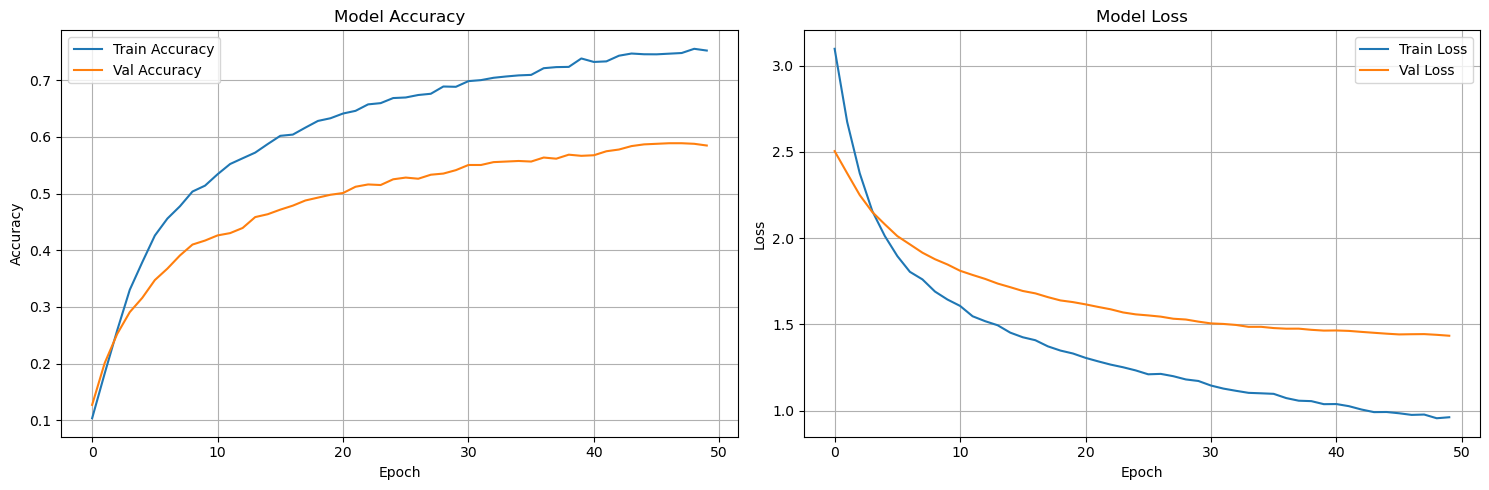

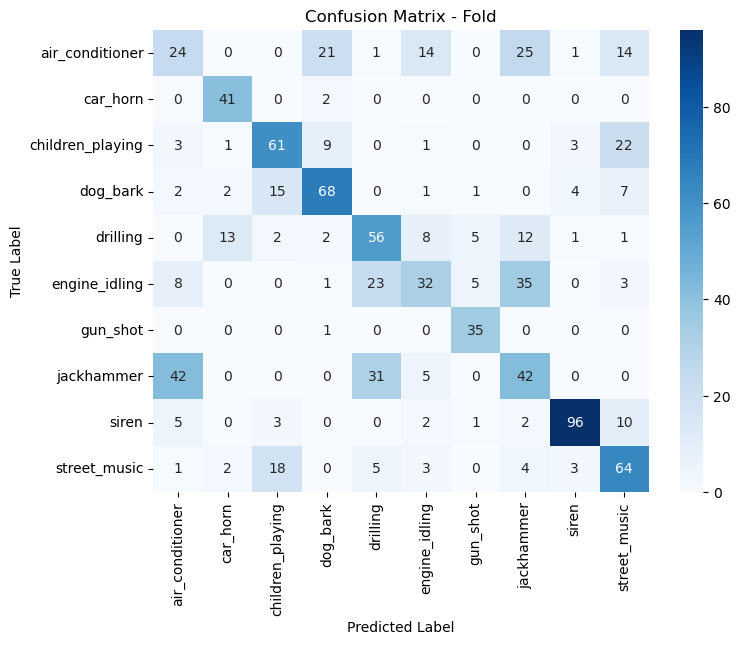


---------------------- FOLD 5 ----------------------
Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1091 - loss: 3.1761 - val_accuracy: 0.1592 - val_loss: 2.5838
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1853 - loss: 2.7225 - val_accuracy: 0.2447 - val_loss: 2.3958
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2644 - loss: 2.4273 - val_accuracy: 0.3483 - val_loss: 2.1875
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3285 - loss: 2.2257 - val_accuracy: 0.4263 - val_loss: 2.0147
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3648 - loss: 2.1033 - val_accuracy: 0.4989 - val_loss: 1.8856
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4080 - loss: 1.9925 - val_accuracy: 0.5374 - val_loss: 1.7913
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4401 - loss: 1.8945 - val_accuracy: 0.5609 - val_loss: 1.7182
Epoch 8/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.

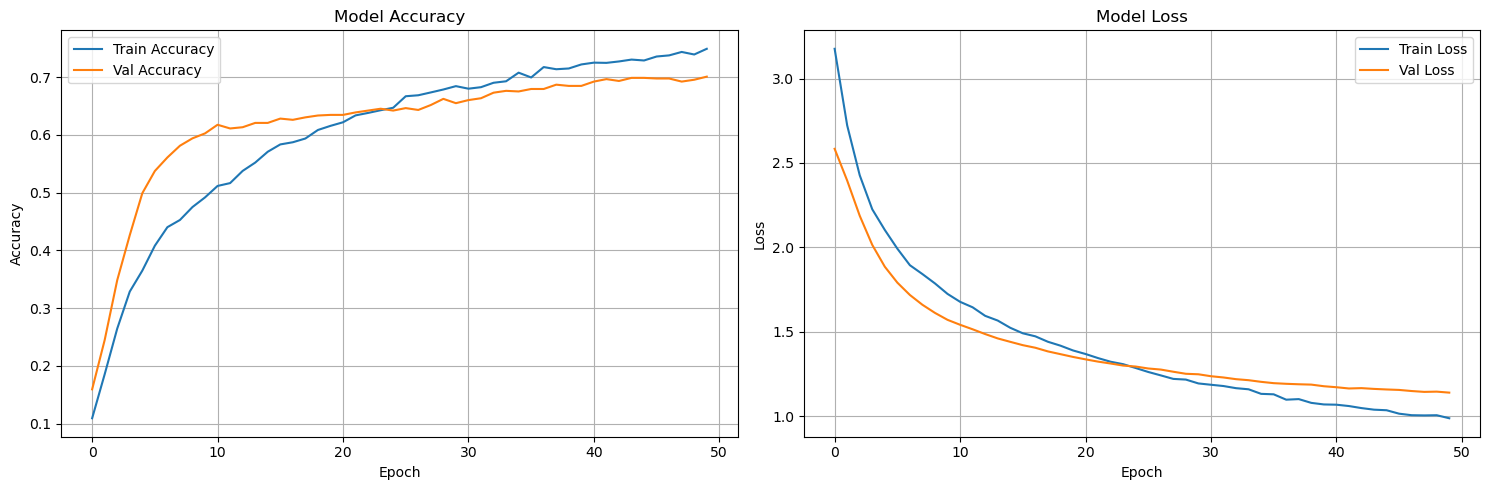

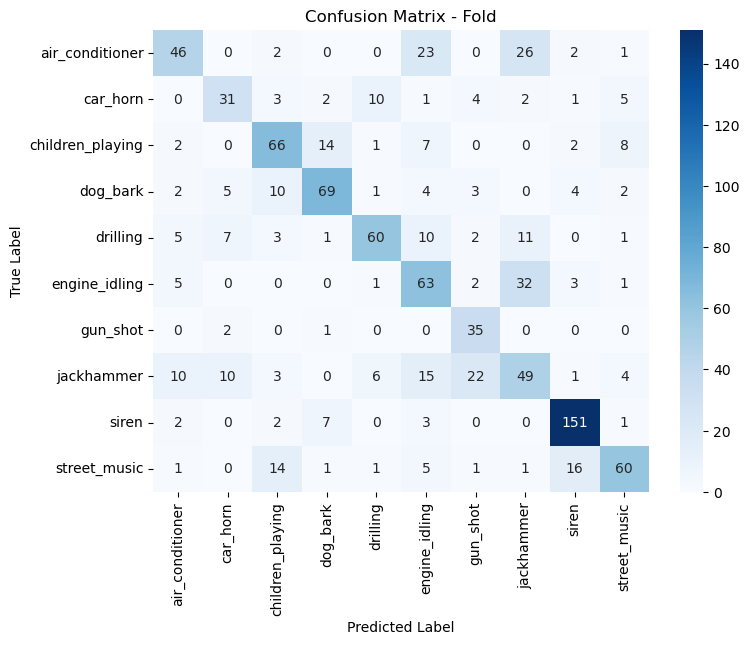


---------------------- FOLD 6 ----------------------
Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1142 - loss: 3.0486 - val_accuracy: 0.1847 - val_loss: 2.4071
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1931 - loss: 2.6382 - val_accuracy: 0.2612 - val_loss: 2.2293
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2624 - loss: 2.3592 - val_accuracy: 0.3183 - val_loss: 2.0620
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3233 - loss: 2.1796 - val_accuracy: 0.3827 - val_loss: 1.9237
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3624 - loss: 2.0478 - val_accuracy: 0.4423 - val_loss: 1.8196
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4048 - loss: 1.9624 - val_accuracy: 0.4800 - val_loss: 1.7387
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4364 - loss: 1.8749 - val_accuracy: 0.4872 - val_loss: 1.6837
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.

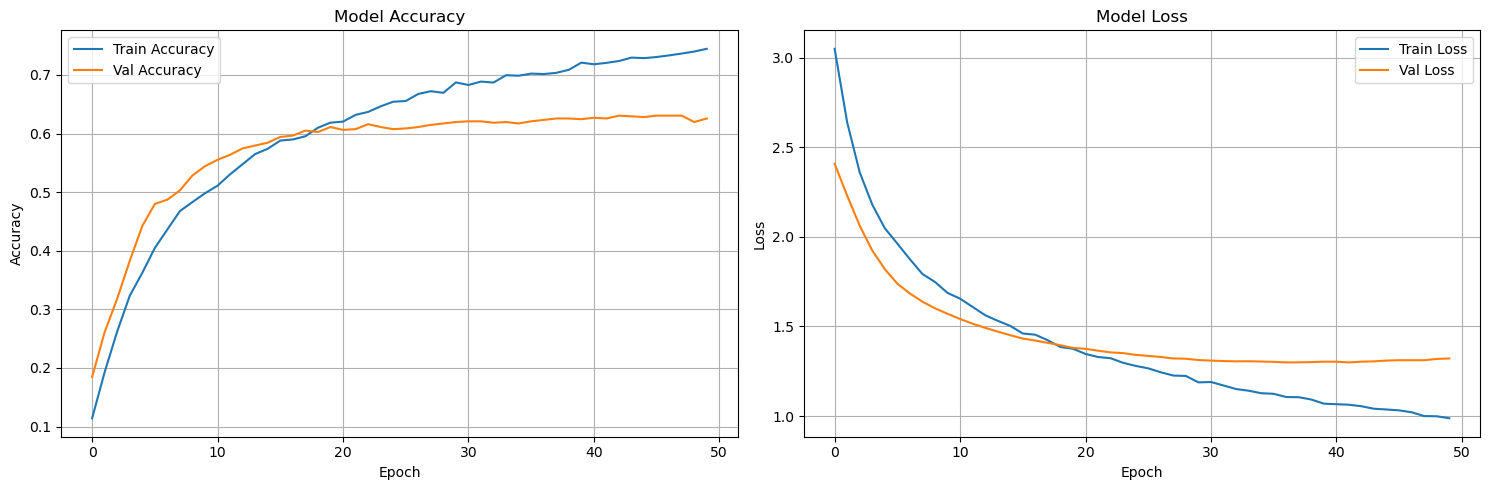

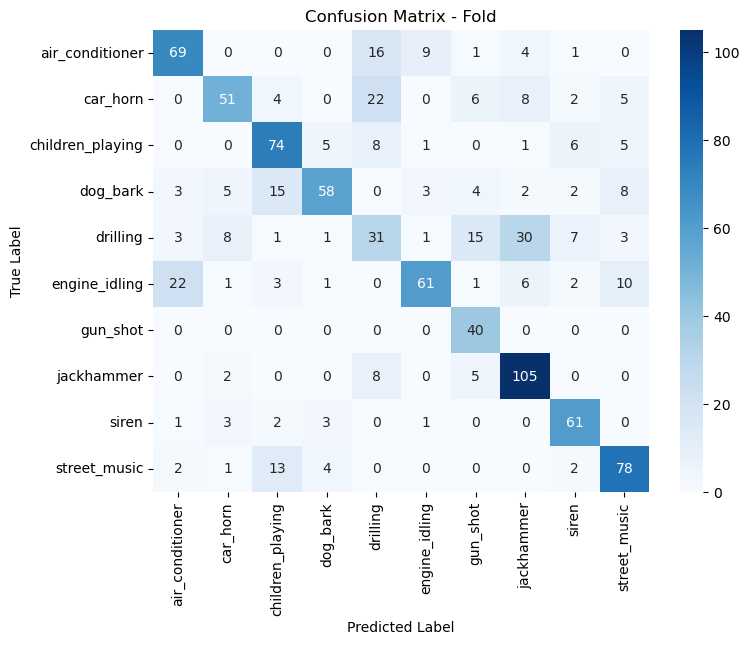


---------------------- FOLD 7 ----------------------
Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1493 - loss: 2.8274 - val_accuracy: 0.1957 - val_loss: 2.3882
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2288 - loss: 2.4669 - val_accuracy: 0.3091 - val_loss: 2.2051
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3047 - loss: 2.2515 - val_accuracy: 0.3377 - val_loss: 2.0754
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3636 - loss: 2.0836 - val_accuracy: 0.3616 - val_loss: 1.9805
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4032 - loss: 1.9686 - val_accuracy: 0.3807 - val_loss: 1.9109
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4435 - loss: 1.8575 - val_accuracy: 0.4033 - val_loss: 1.8610
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4663 - loss: 1.7895 - val_accuracy: 0.4200 - val_loss: 1.8237
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.

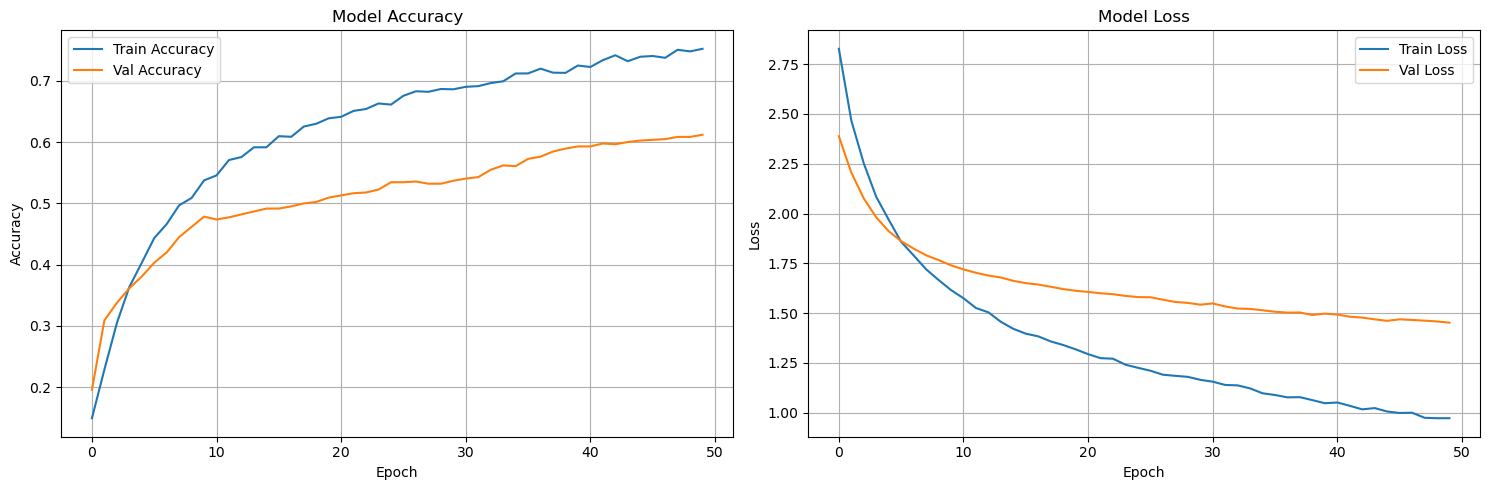

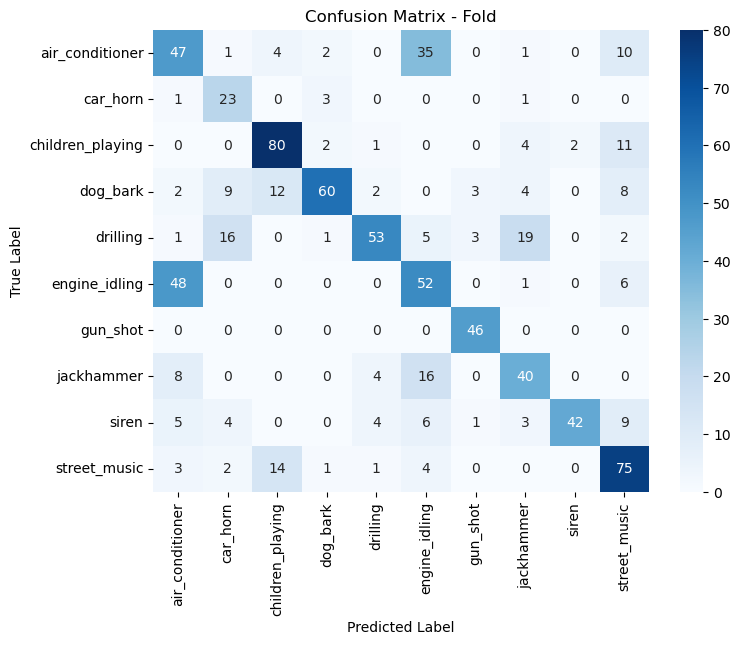


---------------------- FOLD 8 ----------------------
Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1601 - loss: 2.7504 - val_accuracy: 0.1923 - val_loss: 2.4403
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2400 - loss: 2.4178 - val_accuracy: 0.2618 - val_loss: 2.2753
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3058 - loss: 2.2223 - val_accuracy: 0.3635 - val_loss: 2.1123
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3674 - loss: 2.0631 - val_accuracy: 0.4107 - val_loss: 1.9897
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4054 - loss: 1.9634 - val_accuracy: 0.4429 - val_loss: 1.8962
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4391 - loss: 1.8675 - val_accuracy: 0.4578 - val_loss: 1.8260
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4755 - loss: 1.7817 - val_accuracy: 0.4653 - val_loss: 1.7667
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.

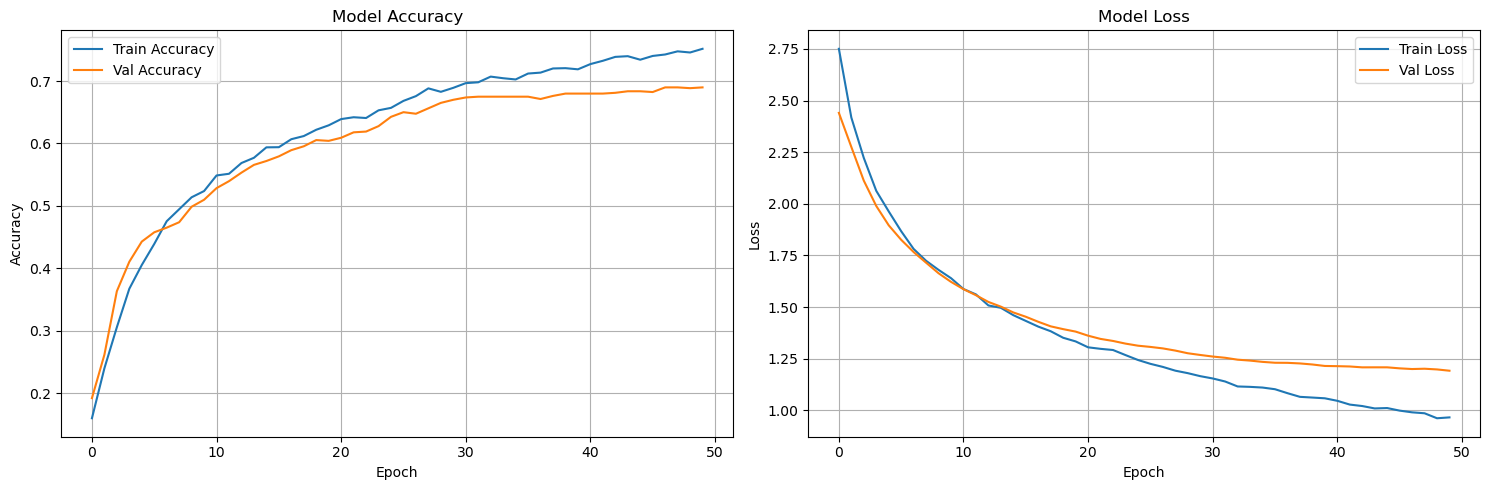

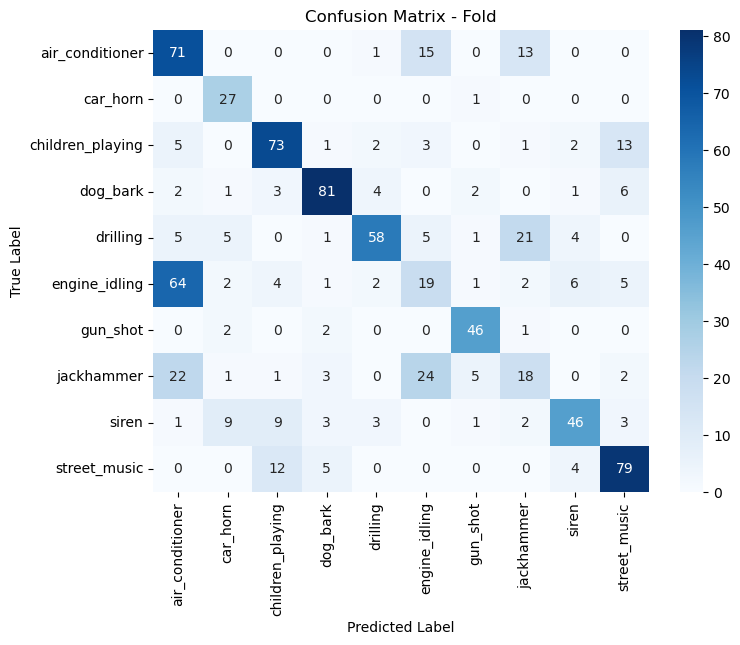


---------------------- FOLD 9 ----------------------
Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1368 - loss: 3.0189 - val_accuracy: 0.1949 - val_loss: 2.4587
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2325 - loss: 2.5404 - val_accuracy: 0.2953 - val_loss: 2.2026
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3077 - loss: 2.2638 - val_accuracy: 0.3591 - val_loss: 2.0367
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3476 - loss: 2.1159 - val_accuracy: 0.4105 - val_loss: 1.9265
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3876 - loss: 1.9956 - val_accuracy: 0.4424 - val_loss: 1.8524
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4155 - loss: 1.8966 - val_accuracy: 0.4522 - val_loss: 1.7906
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4408 - loss: 1.8330 - val_accuracy: 0.4620 - val_loss: 1.7405
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.

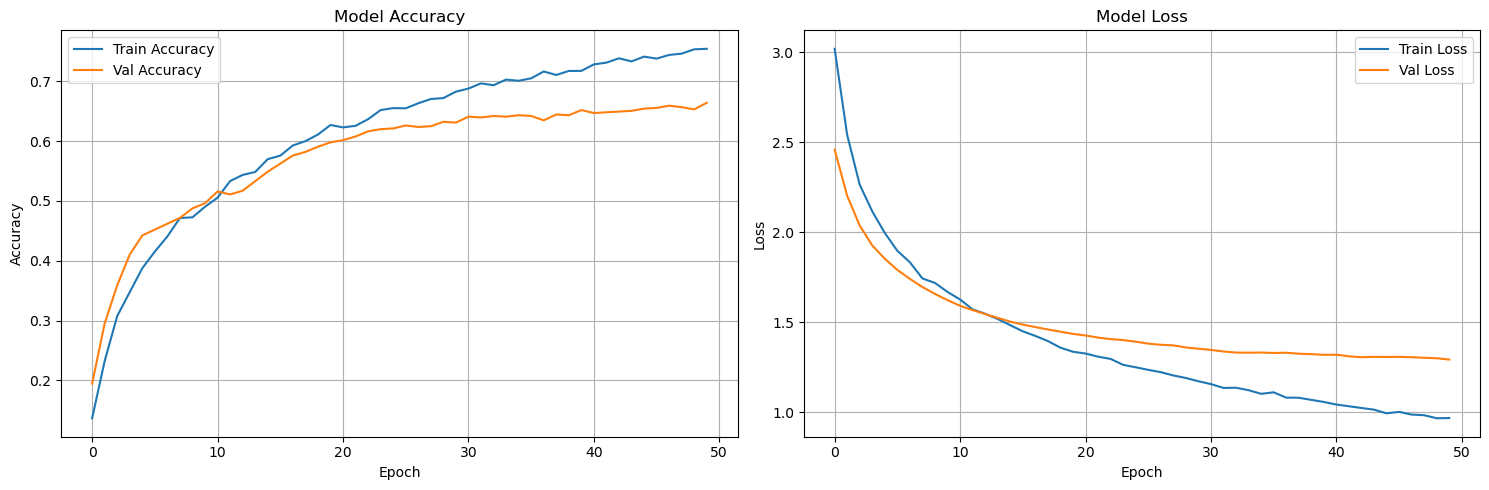

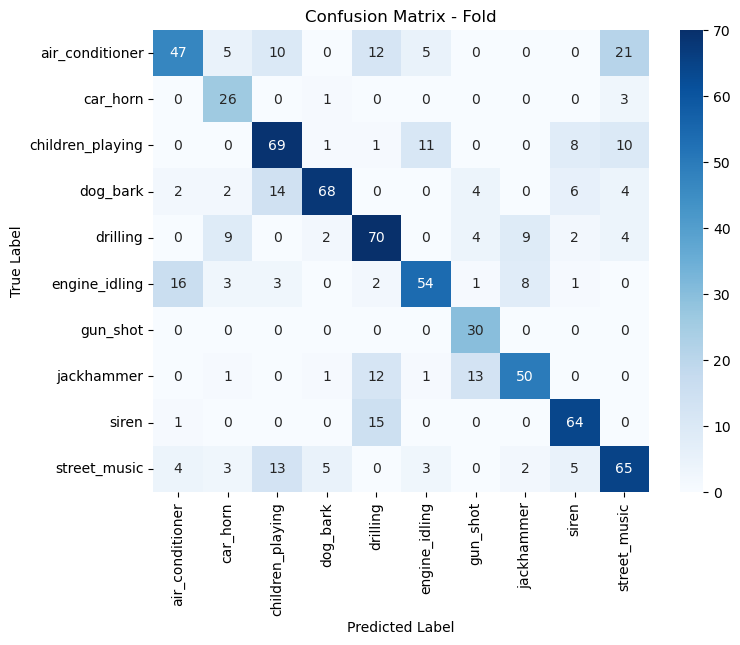


---------------------- FOLD 10 ----------------------
Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1271 - loss: 2.9188 - val_accuracy: 0.2210 - val_loss: 2.4005
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2133 - loss: 2.5506 - val_accuracy: 0.2712 - val_loss: 2.2477
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2829 - loss: 2.2926 - val_accuracy: 0.3094 - val_loss: 2.1012
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3366 - loss: 2.1277 - val_accuracy: 0.3596 - val_loss: 1.9704
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3929 - loss: 1.9840 - val_accuracy: 0.4146 - val_loss: 1.8687
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4189 - loss: 1.9016 - val_accuracy: 0.4516 - val_loss: 1.7850
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4406 - loss: 1.8319 - val_accuracy: 0.4755 - val_loss: 1.7257
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0

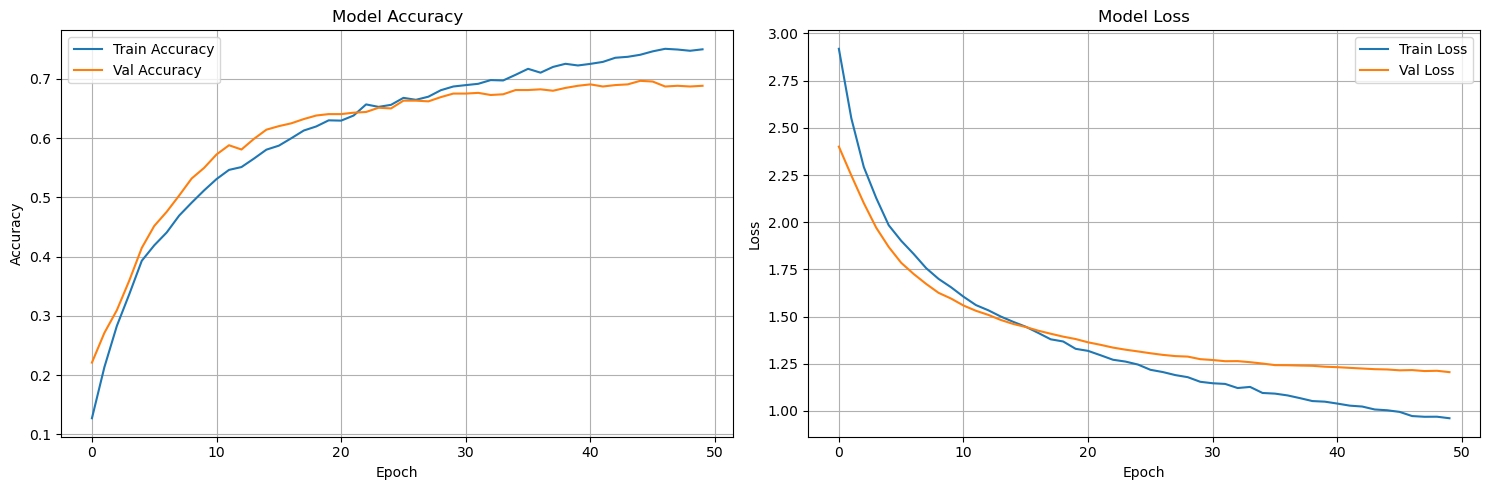

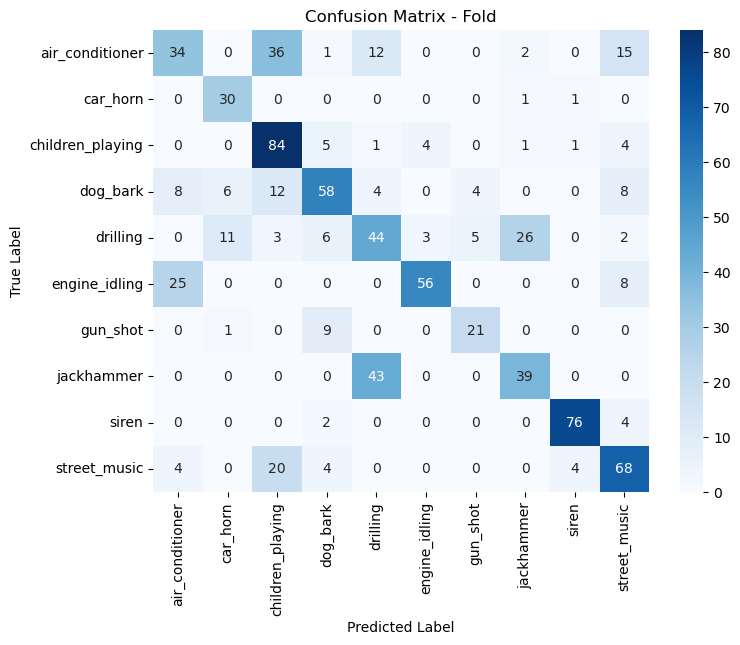


================== RESULTADOS FINAIS ==================
Fold 1: 0.6870
Fold 2: 0.6793
Fold 3: 0.5777
Fold 4: 0.5611
Fold 5: 0.6364
Fold 6: 0.6709
Fold 7: 0.6294
Fold 8: 0.6181
Fold 9: 0.6737
Fold 10: 0.6250

MÉDIA: 0.6359
DESVIO: 0.0408


In [98]:
# Função para plot de métricas e confusion matrix
def plot_graphs(history, y_true, y_pred, class_labels):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # Loss
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_labels,
                yticklabels=class_labels)
    plt.title("Confusion Matrix - Fold")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


# Número de folds
num_folds = len(x_folds_orig)
accuracies = []

# Lista de labels (para os plots)
df = pd.read_csv(metadata_augmented_path)
class_df = df[['classID', 'class']].drop_duplicates().sort_values('classID')
class_labels = class_df['class'].tolist()

print("\n=========== INICIANDO 10-FOLD CROSS-VALIDATION ===========")

for i in range(num_folds):
    print(f"\n---------------------- FOLD {i+1} ----------------------")

    # Definir folds de teste e validação
    test_idx = i
    val_idx = (i+1) % num_folds

    x_test = x_folds_orig[test_idx]
    y_test = y_folds_orig[test_idx]
    x_val = x_folds_orig[val_idx]
    y_val = y_folds_orig[val_idx]

    # Treino: restantes folds
    x_train = np.concatenate([x_folds_orig[j] for j in range(num_folds) if j not in (test_idx, val_idx)])
    y_train = np.concatenate([y_folds_orig[j] for j in range(num_folds) if j not in (test_idx, val_idx)])

    # Adicionar dados augmentados
    x_train_aug = np.concatenate([x_folds_aug[j] for j in range(num_folds) if j not in (test_idx, val_idx)])
    y_train_aug = np.concatenate([y_folds_aug[j] for j in range(num_folds) if j not in (test_idx, val_idx)])

    # Concatenar originais + augmentados
    x_train = np.concatenate([x_train, x_train_aug])
    y_train = np.concatenate([y_train, y_train_aug])

    # Normalização baseada no treino
    mean = x_train.mean(axis=0)
    std = x_train.std(axis=0) + 1e-9
    x_train = (x_train - mean) / std
    x_val   = (x_val - mean) / std
    x_test  = (x_test - mean) / std

    # One-hot encoding das labels
    y_train = to_categorical(y_train, 10)
    y_val   = to_categorical(y_val, 10)
    y_test  = to_categorical(y_test, 10)

    # Criar modelo MLP
    model = create_mlp_model(input_shape=x_train.shape[1:])

    # EarlyStopping
    es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

    # Treino
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        batch_size=128,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    # Avaliação
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    accuracies.append(acc)
    print(f"Accuracy da Fold {i+1}: {acc:.4f}")

    # Previsão para plot
    y_pred_probs = model.predict(x_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_test_labels = np.argmax(y_test, axis=1)

    # Plots
    plot_graphs(history, y_test_labels, y_pred, class_labels)

# Resultados finais
print("\n================== RESULTADOS FINAIS ==================")
for i, a in enumerate(accuracies, 1):
    print(f"Fold {i}: {a:.4f}")
print(f"\nMÉDIA: {np.mean(accuracies):.4f}")
print(f"DESVIO: {np.std(accuracies):.4f}")


A análise dos resultados do treino inicial revela uma média de accuracy de 0.6359, com um desvio padrão de 0.0408. Estes valores indicam que, mesmo sem ajustes finos nos hiperparâmetros, o modelo consegue extrair informação útil das features e classificar corretamente mais de 63% dos exemplos.

*Nota sobre o conjunto de dados utilizado na avaliação*

Para a avaliação do desempenho dos modelos, optou-se por apresentar apenas os resultados obtidos com o conjunto de dados aumentado (data augmentation).
Esta decisão foi tomada por uma questão de consistência com a implementação final: a pipeline construída ao longo do trabalho foi otimizada para operar com augmentation e modificar toda a estrutura para suportar versões paralelas sem augmentation introduziria alterações extensas e não essenciais para os objetivos da análise.


## 3. Training strategies


Para treinar o nosso modelo MLP de forma eficaz e reduzir o risco de overfitting, adotamos várias estratégias de treino. Em primeiro lugar, aplicamos **early stopping**, que monitora a função de perda de validação e interrompe o treino quando esta deixa de melhorar durante um certo número de épocas, garantindo que o modelo não treine em excesso.
Além disso, utilizamos **regularização L2** em todas as camadas densas, que penaliza pesos muito grandes, e **dropout**, que desliga aleatoriamente uma fração dos neurónios durante o treino para aumentar a robustez do modelo. Para normalizar a activação das camadas e acelerar a convergência, incluímos **batch normalization** após cada camada densa.
Como o desempenho do modelo depende fortemente dos hiperparâmetros (número de neurónios por camada, taxa de dropout, taxa de aprendizagem, ativação, etc.), adotamos uma estratégia de **Fine-Tuning com Random Search**. Esta abordagem permite explorar uma vasta combinação de valores de hiperparâmetros e selecionar aqueles que maximizam a performance média do modelo em 10-fold cross-validation, garantindo uma escolha mais robusta e generalizável.

### 3.1. Fine-tuning com Random Search


Definição da função para criar o modelo MLP parametrizável e do espaço de hiperparâmetros a explorar no Random Search.


In [ ]:
def create_mlp_model_hp(input_shape,
                        n1, n2, n3,
                        dropout1, dropout2, dropout3,
                        l2_reg, lr,
                        activation='relu',
                        optimizer='adam',
                        num_classes=10):

    # Escolher otimizador
    if optimizer.lower() == 'adam':
        opt = Adam(learning_rate=lr)
    elif optimizer.lower() == 'nadam':
        opt = Nadam(learning_rate=lr)
    else:
        raise ValueError(f"Optimizer {optimizer} não reconhecido.")

    model = Sequential()
    model.add(Input(shape=(input_shape,)))

    model.add(Dense(n1, activation=activation, kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout1))

    model.add(Dense(n2, activation=activation, kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout2))

    model.add(Dense(n3, activation=activation, kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout3))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer=opt,
        metrics=['accuracy']
    )
    return model


In [115]:
param_space = {
    "n1": [128, 192, 256, 320],
    "n2": [64, 96, 128, 160],
    "n3": [32, 48, 64, 80],

    "dropout1": [0.1, 0.2, 0.3, 0.4],
    "dropout2": [0.1, 0.15, 0.2, 0.25],
    "dropout3": [0.05, 0.1, 0.15],

    "l2_reg": [1e-2, 5e-3, 1e-3, 1e-4, 1e-5],

    "lr": [1e-5, 3e-5, 1e-4, 3e-4, 1e-3],

    "batch_size": [32, 64, 128],

    "activation": ["relu", "elu"],
    "optimizer": ["adam", "nadam"]
}

Avaliação de um conjunto de hiperparâmetros usando 10-fold cross-validation, retornando a média de accuracy.

In [116]:
def evaluate_params_cv(params, epochs=25, verbose=0):
    fold_accuracies = []

    for i in range(num_folds):

        test_idx = i
        val_idx  = (i + 1) % num_folds

        # Dados
        x_test = x_folds_orig[test_idx].copy()
        y_test = y_folds_orig[test_idx].copy()

        x_val  = x_folds_orig[val_idx].copy()
        y_val  = y_folds_orig[val_idx].copy()

        # Treino (todos excepto test/val)
        x_train = np.concatenate([
            x_folds_orig[j] for j in range(num_folds) if j not in (test_idx, val_idx)
        ])
        y_train = np.concatenate([
            y_folds_orig[j] for j in range(num_folds) if j not in (test_idx, val_idx)
        ])

        # Augment
        x_train_aug = np.concatenate([
            x_folds_aug[j] for j in range(num_folds) if j not in (test_idx, val_idx)
        ])
        y_train_aug = np.concatenate([
            y_folds_aug[j] for j in range(num_folds) if j not in (test_idx, val_idx)
        ])

        x_train = np.concatenate([x_train, x_train_aug])
        y_train = np.concatenate([y_train, y_train_aug])

        # Normalização
        mean = x_train.mean(axis=0)
        std  = x_train.std(axis=0) + 1e-9

        x_train = (x_train - mean) / std
        x_val   = (x_val  - mean) / std
        x_test  = (x_test - mean) / std

        # One hot
        y_train_cat = to_categorical(y_train, 10)
        y_val_cat   = to_categorical(y_val,   10)
        y_test_cat  = to_categorical(y_test,  10)

        model = create_mlp_model_hp(
            input_shape=x_train.shape[1],
            n1=params['n1'], n2=params['n2'], n3=params['n3'],
            dropout1=params['dropout1'], dropout2=params['dropout2'],
            dropout3=params['dropout3'],
            l2_reg=params['l2_reg'],
            lr=params['lr'],
            activation=params['activation'],
            optimizer=params['optimizer'],
            num_classes=10
        )

        es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

        model.fit(
            x_train, y_train_cat,
            validation_data=(x_val, y_val_cat),
            epochs=epochs,
            batch_size=params['batch_size'],
            callbacks=[es],
            verbose=verbose
        )

        loss, acc = model.evaluate(x_test, y_test_cat, verbose=0)
        fold_accuracies.append(acc)

    return float(np.mean(fold_accuracies))


Execução de várias amostras aleatórias do espaço de hiperparâmetros, identificando o melhor conjunto segundo a média de accuracy nos 10 folds.

In [ ]:
random.seed(42)
np.random.seed(42)

N_SEARCH = 40  # podes aumentar até 60 se quiseres
best_score = -1
best_params = None

print(f"Random Search iniciado com {N_SEARCH} amostras...\n")
start_all = time.time()

for i in range(1, N_SEARCH+1):

    params = {k: random.choice(v) for k, v in param_space.items()}

    print(f"\n=== [{i}/{N_SEARCH}] Testando parâmetros ===")
    print(params)

    score = evaluate_params_cv(params, epochs=20, verbose=0)

    print(f" → Accuracy médio nos 10 folds = {score:.4f}")

    if score > best_score:
        best_score = score
        best_params = params
        print("   ✔ Novo melhor conjunto encontrado!")

elapsed = time.time() - start_all

print("\n================== RANDOM SEARCH TERMINADO ==================")
print("Melhores parâmetros:", best_params)
print(f"Melhor média nos 10 folds: {best_score:.4f}")
print(f"Tempo total: {elapsed/60:.1f} min")


Random Search iniciado com 40 amostras...


=== [1/40] Testando parâmetros ===
{'n1': 128, 'n2': 64, 'n3': 64, 'dropout1': 0.2, 'dropout2': 0.15, 'dropout3': 0.05, 'l2_reg': 0.01, 'lr': 0.001, 'batch_size': 32, 'activation': 'elu', 'optimizer': 'adam'}
 → Accuracy médio nos 10 folds = 0.6409
   ✔ Novo melhor conjunto encontrado!

=== [2/40] Testando parâmetros ===
{'n1': 128, 'n2': 160, 'n3': 64, 'dropout1': 0.4, 'dropout2': 0.2, 'dropout3': 0.05, 'l2_reg': 0.001, 'lr': 0.0001, 'batch_size': 32, 'activation': 'elu', 'optimizer': 'adam'}
 → Accuracy médio nos 10 folds = 0.6395

=== [3/40] Testando parâmetros ===
{'n1': 320, 'n2': 64, 'n3': 80, 'dropout1': 0.4, 'dropout2': 0.25, 'dropout3': 0.15, 'l2_reg': 0.001, 'lr': 0.001, 'batch_size': 32, 'activation': 'relu', 'optimizer': 'nadam'}
 → Accuracy médio nos 10 folds = 0.6600
   ✔ Novo melhor conjunto encontrado!

=== [4/40] Testando parâmetros ===
{'n1': 320, 'n2': 96, 'n3': 48, 'dropout1': 0.3, 'dropout2': 0.25, 'dropout3': 0.15, 'l2_r

## 4. Performance evaluation

Treino do modelo MLP em cada fold usando os melhores hiperparâmetros encontrados.

In [ ]:
models = []
means = []
stds = []
x_tests_raw = []
y_tests_raw = []
histories = []

accuracies_final = []
num_folds = len(x_folds_orig)

print("\nRe-executando 10-fold final com best_params e guardando modelos/stats por fold...")

for i in range(num_folds):
    test_idx = i
    val_idx = (i + 1) % num_folds

    x_test_raw = x_folds_orig[test_idx].copy()   # sem normalizar
    y_test_raw = y_folds_orig[test_idx].copy()
    x_val = x_folds_orig[val_idx].copy()
    y_val = y_folds_orig[val_idx].copy()

    x_train = np.concatenate([x_folds_orig[j] for j in range(num_folds) if j not in (test_idx, val_idx)])
    y_train = np.concatenate([y_folds_orig[j] for j in range(num_folds) if j not in (test_idx, val_idx)])

    x_train_aug = np.concatenate([x_folds_aug[j] for j in range(num_folds) if j not in (test_idx, val_idx)])
    y_train_aug = np.concatenate([y_folds_aug[j] for j in range(num_folds) if j not in (test_idx, val_idx)])

    x_train = np.concatenate([x_train, x_train_aug])
    y_train = np.concatenate([y_train, y_train_aug])

    # mean/std (guardar)
    mean = x_train.mean(axis=0)
    std = x_train.std(axis=0) + 1e-9
    means.append(mean)
    stds.append(std)

    # guardar x_test_raw e y_test_raw
    x_tests_raw.append(x_test_raw.copy())
    y_tests_raw.append(y_test_raw.copy())

    # normalizar para treino
    x_train_n = (x_train - mean) / std
    x_val_n   = (x_val - mean) / std
    x_test_n  = (x_test_raw - mean) / std

    # one-hot
    y_train_cat = to_categorical(y_train, 10)
    y_val_cat = to_categorical(y_val, 10)
    y_test_cat = to_categorical(y_test_raw, 10)

    # criar modelo com best_params
    model = create_mlp_model_hp(
        input_shape=x_train_n.shape[1],
        n1=best_params['n1'], n2=best_params['n2'], n3=best_params['n3'],
        dropout1=best_params['dropout1'], dropout2=best_params['dropout2'], dropout3=best_params['dropout3'],
        l2_reg=best_params['l2_reg'], lr=best_params['lr'],
        num_classes=10
    )

    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        x_train_n, y_train_cat,
        validation_data=(x_val_n, y_val_cat),
        epochs=50,
        batch_size=best_params['batch_size'],
        callbacks=[es],
        verbose=1
    )

    histories.append(history)
    models.append(model)

    loss, acc = model.evaluate(x_test_n, y_test_cat, verbose=0)
    accuracies_final.append(acc)
    print(f"Fold {i+1} accuracy (final): {acc:.4f}")

print("\nRESULTADOS FINAIS (com best_params):")
for i, a in enumerate(accuracies_final, 1):
    print(f"Fold {i}: {a:.4f}")
print(f"\nMÉDIA: {np.mean(accuracies_final):.4f}")
print(f"DESVIO: {np.std(accuracies_final):.4f}")



Re-executando 10-fold final com best_params e guardando modelos/stats por fold...
Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5456 - loss: 1.7679 - val_accuracy: 0.6518 - val_loss: 1.7371
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7383 - loss: 1.2301 - val_accuracy: 0.6346 - val_loss: 1.5050
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7758 - loss: 1.0763 - val_accuracy: 0.6346 - val_loss: 1.4920
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8136 - loss: 0.9649 - val_accuracy: 0.6254 - val_loss: 1.4571
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8381 - loss: 0.8802 - val_accuracy: 0.6140 - val_loss: 1.5688
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8502 - loss: 0.8353 - val_accuracy: 0.6289 - val_loss: 1.5261
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8678 - loss: 0.7583 - val_accuracy: 0.6289 - val_loss: 1.6197
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━

Após a execução do Random Search para otimização de hiperparâmetros, a média de accuracy aumenta para 0.6537, mantendo o mesmo desvio padrão. Este aumento, embora modesto, indica que a escolha de melhores parâmetros de rede, dropout, regularização e taxa de aprendizagem permite ao modelo generalizar melhor sobre os dados de teste.

### 4.1 DeepFool

Complementar a avaliação de performance, verificando não apenas a accuracy, mas também a resistência do modelo a inputs ligeiramente alterados através do DeepFool. O mesmo vai gerar pequenas alterações nos dados de teste e analisar a suscetibilidade do modelo a erros induzidos por perturbações mínimas.

In [ ]:
def build_logits_model_from_sequential(model, input_shape):
    """
    Cria um modelo funcional que devolve os logits a partir de um Sequential MLP.
    Funciona mesmo que o Sequential nunca tenha sido chamado.
    """
    x_input = Input(shape=(input_shape,))
    x = x_input
    for layer in model.layers[:-1]:  # todas exceto a última softmax
        x = layer(x)
    
    # Última camada: logits (sem softmax)
    W, b = model.layers[-1].get_weights()
    logits_layer = Dense(
        units=W.shape[1],
        activation=None,
        kernel_initializer=tf.constant_initializer(W),
        bias_initializer=tf.constant_initializer(b),
        trainable=False
    )(x)
    
    logits_model = Model(inputs=x_input, outputs=logits_layer)
    return logits_model


In [ ]:
def deepfool_on_fold(fold_idx, models, means, stds, x_tests_raw, max_iter=50, overshoot=0.02):
    """
    Aplica DeepFool a uma fold inteira.
    Retorna taxa de sucesso e normas das perturbações.
    """
    model = models[fold_idx]
    mean = means[fold_idx]
    std  = stds[fold_idx]

    X_raw = x_tests_raw[fold_idx]
    X_norm = (X_raw - mean) / std

    input_shape = X_norm.shape[1]
    logits_model = build_logits_model_from_sequential(model, input_shape)

    success_count = 0
    perturb_norms = []

    for i in range(len(X_norm)):
        x0 = tf.convert_to_tensor(X_norm[i:i+1], dtype=tf.float32)
        f_image = logits_model(x0)
        k_i = tf.argmax(f_image[0]).numpy()

        r_tot = tf.zeros_like(x0)
        x = x0

        for iter in range(max_iter):
            with tf.GradientTape() as tape:
                tape.watch(x)
                fs = logits_model(x)[0]
                f_k = fs[k_i]
            grad_orig = tape.gradient(f_k, x)

            # calcular mínimos gradientes
            perturbs = []
            for k in range(fs.shape[0]):
                if k == k_i:
                    continue
                with tf.GradientTape() as tape2:
                    tape2.watch(x)
                    f_k_new = logits_model(x)[0, k]
                grad_k = tape2.gradient(f_k_new, x)
                w_k = grad_k - grad_orig
                f_k_diff = fs[k] - fs[k_i]
                pert_k = tf.abs(f_k_diff) / (tf.norm(tf.reshape(w_k, [-1])) + 1e-12) * tf.sign(w_k)
                perturbs.append(tf.reshape(pert_k, x.shape))

            perturbs = tf.stack(perturbs)
            r_i = perturbs[tf.argmin(tf.norm(tf.reshape(perturbs, (perturbs.shape[0], -1)), axis=1))]
            r_tot += r_i
            x_adv = x + (1 + overshoot) * r_tot
            x = x_adv

            if tf.argmax(logits_model(x)[0]).numpy() != k_i:
                success_count += 1
                perturb_norms.append(tf.norm(tf.reshape(r_tot, [-1])).numpy())
                break
        else:
            # se não conseguir, ainda guarda a norma final
            perturb_norms.append(tf.norm(tf.reshape(r_tot, [-1])).numpy())

    success_rate = success_count / len(X_norm)
    return {'success_rate': success_rate, 'norms': perturb_norms}


In [121]:
deepfool_results = []

for fold in range(len(models)):
    print(f"Fold {fold+1}")
    res = deepfool_on_fold(fold, models, means, stds, x_tests_raw)
    deepfool_results.append(res)
    print(f"  Success Rate: {res['success_rate']:.4f}")
    print(f"  Avg Perturb Norm: {np.mean(res['norms']):.6f}\n")


Fold 1
  Success Rate: 1.0000
  Avg Perturb Norm: 7.933596

Fold 2
  Success Rate: 1.0000
  Avg Perturb Norm: 7.768886

Fold 3
  Success Rate: 1.0000
  Avg Perturb Norm: 6.809836

Fold 4
  Success Rate: 1.0000
  Avg Perturb Norm: 6.756073

Fold 5
  Success Rate: 1.0000
  Avg Perturb Norm: 5.417061

Fold 6
  Success Rate: 1.0000
  Avg Perturb Norm: 7.371710

Fold 7
  Success Rate: 1.0000
  Avg Perturb Norm: 6.657372

Fold 8
  Success Rate: 1.0000
  Avg Perturb Norm: 5.969828

Fold 9
  Success Rate: 1.0000
  Avg Perturb Norm: 7.274496

Fold 10
  Success Rate: 1.0000
  Avg Perturb Norm: 8.952154



In [128]:
all_norms = np.concatenate([res["norms"] for res in deepfool_results])
mean_norm = np.mean(all_norms)
std_norm = np.std(all_norms)

success_rates = [res["success_rate"] for res in deepfool_results]
mean_sr = np.mean(success_rates)
std_sr = np.std(success_rates)

print("============== DEEPFOOL FINAL RESULTS  ==============")
print(f"Success Rate (mean over folds): {mean_sr:.4f} ± {std_sr:.4f}")
print(f"Perturbation Norm (mean): {mean_norm:.6f} ± {std_norm:.6f}")


============== DEEPFOOL FINAL RESULTS  ==============
Success Rate (mean over folds): 1.0000 ± 0.0000
Perturbation Norm (mean): 7.058166 ± 7.500334


No contexto do MLP, o DeepFool ajuda a compreender até que ponto o modelo depende de padrões específicos das features extraídas (MFCCs, espectro, cromas, etc.), dado que a arquitetura não explora relações espaciais como numa CNN, mas sim combina as features de forma totalmente conectada.
Os resultados obtidos foram:

- Success Rate (média sobre folds): 1.0000 ± 0.0000
    - Isto indica que o DeepFool conseguiu alterar a classificação de todos os exemplos de teste em todas as folds, mostrando que o modelo, apesar de ter uma boa accuracy, é altamente sensível a pequenas perturbações nas entradas.

- Perturbation Norm (média): 7.058 ± 7.500
    - A magnitude das alterações necessárias para enganar o modelo é relativamente pequena, mas apresenta elevada variabilidade, sugerindo que alguns exemplos necessitam de mudanças mínimas para serem classificados incorretamente, enquanto outros exigem perturbações maiores.
        
Esta análise evidencia que, embora o MLP apresente uma performance aceitável nos testes (accuracy média ~65%), a sua robustez face a pequenas alterações nas features é limitada, reforçando a importância de considerar métodos de regularização, augmentação de dados ou arquiteturas mais complexas em aplicações onde a segurança e confiabilidade do modelo são críticas.